# Real-Time Credit Card Fraud Detection Using Machine Learning

---
embed-resources: true
echo: false
---

---
format:
  html:
    toc: true
    toc-location: left
    toc-depth: 3
    number-sections: true
embed-resources: true
echo: false
---

## Introduction

This report evaluates a machine learning approach for real-time credit card fraud detection in a banking setting. The purpose of the analysis is to determine whether transaction-level information available at the moment of purchase can be used to identify fraudulent activity quickly and accurately enough to support fraud prevention decisions. This is an important problem because fraud is costly to both banks and customers, but overly aggressive fraud detection can also block legitimate purchases and create customer frustration. The goal of the report is therefore not simply to maximize overall accuracy, but to find a model that balances catching fraudulent transactions with minimizing false alarms. The analysis uses labeled credit card transaction data containing transaction amount and 28 privacy-preserving principal component features, and the final model used in the notebook is a histogram-based gradient boosting classifier.

## Methods

### Imports

In [1]:
from joblib import dump
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

### Data

The data for this lab originally comes from Kaggle. Citations for the data can be found on Kaggle.

- [Kaggle: Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/)
A brief description of the target variable is given.

> This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

Similarly, a brief description of the feature variables is given.

> It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are ‘Time’ and ‘Amount’. Feature ‘Time’ contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature ‘Amount’ is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature ‘Class’ is the response variable and it takes value 1 in case of fraud and 0 otherwise.

We are providing a modified version of this data for this lab.

Modifications include:

Removed the `Time` variable as it is misleading.
Reduced the number of samples, while maintaining the number of fraudulent transactions.
- The class imbalance is reduced, but the target is still highly imbalanced.
Withheld some data that will be considered the production data.
Renamed the target variable from `Class` to `Fraud`.
Renamed the PCA transformed variables.

In [2]:
# load data
fraud_train = pd.read_parquet(
    "https://lab.cs307.org/fraud/data/fraud-train.parquet",
)
fraud_test = pd.read_parquet(
    "https://lab.cs307.org/fraud/data/fraud-test.parquet",
)

### Data Dictionary

Each observation in the train, test, and (hidden) production data contains information about a particular credit card transaction.

#### Variable Descriptions:

**`Fraud`**

- `[int64]` status of the transaction. `1` indicates a fraudulent transaction and `0` indicates not fraud, a genuine transaction.

**`Amount`**

- `[float64]` amount (in dollars) of the transaction.

**`PC01`** - **`PC28`**

- `[float64]` the 28 principal components that encode information such as location and type of purchase while preserving customer privacy.

### Summary Statistics

#### 1. Number of samples/feature

In [3]:
n_samples = fraud_train.shape[0]
n_features = fraud_train.drop(columns="Fraud").shape[1]

print("# Samples:", n_samples)
print("# Features:", n_features)

# Samples: 54276
# Features: 29


#### 2. Fraud Balance

@fig-class-balance shows that fraudulent transactions are extremely rare compared with genuine transactions. This matters because a model could achieve very high accuracy by simply predicting every transaction as non-fraud. As a result, overall accuracy is not enough for this problem, and the analysis should focus more on metrics such as precision, recall, and F1 score.

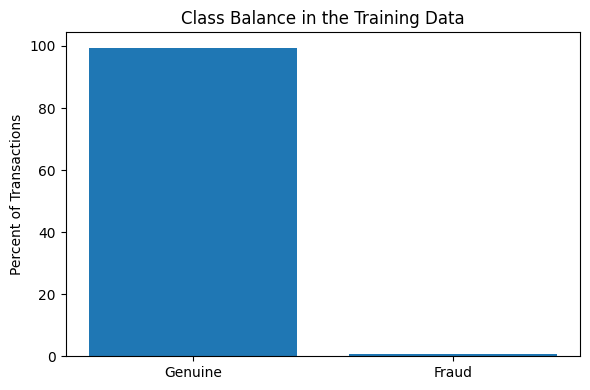

In [4]:
#| label: fig-class-balance
#| fig-cap: "Class balance in the training data. Fraudulent transactions make up only a very small share of all transactions, highlighting the severe class imbalance in the fraud detection problem."

class_pct = (
    fraud_train["Fraud"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

class_counts = (
    fraud_train["Fraud"]
    .value_counts()
    .sort_index()
)

labels = ["Genuine", "Fraud"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, class_pct.values)
ax.set_title("Class Balance in the Training Data")
ax.set_ylabel("Percent of Transactions")
plt.tight_layout()
plt.show()

In [5]:
balance = (
    fraud_train["Fraud"]
    .value_counts()
    .sort_index()
    .rename_axis("Label")
    .reset_index(name="Count")
)

balance["Proportion"] = balance["Count"] / len(fraud_train)

print("\nFraud Balance:")
print(balance)


Fraud Balance:
   Label  Count  Proportion
0      0  53961    0.994196
1      1    315    0.005804


#### 3. Amount Summary Stats

In [6]:
overall_stats = fraud_train["Amount"].agg(
    Mean="mean",
    Standard_Deviation="std",
    Median="median",
    Maximum="max"
)

genuine_stats = fraud_train.loc[fraud_train["Fraud"] == 0, "Amount"].agg(
    Mean="mean",
    Standard_Deviation="std",
    Median="median",
    Maximum="max"
)

fraud_stats = fraud_train.loc[fraud_train["Fraud"] == 1, "Amount"].agg(
    Mean="mean",
    Standard_Deviation="std",
    Median="median",
    Maximum="max"
)

amount_summary = pd.DataFrame(
    [overall_stats, genuine_stats, fraud_stats],
    index=["None", "0 (Genuine)", "1 (Fraud)"]
)

print("\nAmount Summary:")
print(amount_summary)


Amount Summary:
                   Mean  Standard_Deviation  Median   Maximum
None          88.197903          241.535617   21.69  10199.44
0 (Genuine)   88.065104          241.451144   21.80  10199.44
1 (Fraud)    110.947016          254.978960    6.99   2125.87


### Models

#### Prepare Data for Machine Learning

Create the X and y variants of the data for use with sklearn:

In [7]:
X_train = fraud_train.drop(columns="Fraud")
y_train = fraud_train["Fraud"]

X_test = fraud_test.drop(columns="Fraud")
y_test = fraud_test["Fraud"]

Since fraudulent transactions typically constitute a minority of the data, we assign a higher weight to the positive class here, so that the model places greater emphasis on identifying fraudulent transactions. 

In [8]:
sample_weight = np.where(y_train == 1, 6, 1)

The model ultimately used was the HistGradientBoostingClassifier. This model is well-suited for this problem because it can capture nonlinear relationships and interactions among features without requiring extensive manual feature engineering, and it performs exceptionally well on imbalanced datasets.

In [9]:
final_model = HistGradientBoostingClassifier(
    learning_rate=0.03,
    max_iter=400,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1.0,
    random_state=42,
)

In [10]:
final_model.fit(X_train, y_train, sample_weight=sample_weight)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.03
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",400
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",1.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_d

## Results

In [11]:
y_test_pred = final_model.predict(X_test)

print("Test precision:", round(precision_score(y_test, y_test_pred, zero_division=0), 4))
print("Test recall:", round(recall_score(y_test, y_test_pred, zero_division=0), 4))
print("Test F1:", round(f1_score(y_test, y_test_pred, zero_division=0), 4))

Test precision: 0.9848
Test recall: 0.8228
Test F1: 0.8966


The final fraud detection model performed strongly on the held-out test data. It achieved a precision of 0.9848, a recall of 0.8228, and an F1 score of 0.8966. These results indicate that when the model predicts fraud, it is almost always correct, while still detecting a large majority of the fraudulent transactions in the test set.

The confusion matrix gives a clearer business interpretation of these results. Out of 79 fraudulent transactions in the test set, the model correctly identified 65 and missed 14. Out of 13,490 genuine transactions, it incorrectly flagged only 1. This means the model produced almost no false alarms while still catching most fraud cases. For a banking use case, that is a strong result because excessive false positives can interrupt valid customer purchases and damage trust.

The confusion matrix is the most useful visualization for communicating model performance because it directly shows the tradeoff between stopping fraud and avoiding disruption to legitimate users. As shown in @fig-final-confusion, the final model catches most fraudulent transactions while producing almost no false alarms on legitimate purchases.

In [12]:
confusion_matrix(y_test, y_test_pred)

array([[13489,     1],
       [   14,    65]])

### Summary Figure

@fig-final-confusion provides the clearest summary of the final model's performance. The model correctly detected 65 fraudulent transactions and missed 14, while incorrectly flagging only 1 genuine transaction as fraud. This indicates that the model is very precise and creates very little unnecessary friction for legitimate customers, while still catching most fraud cases.

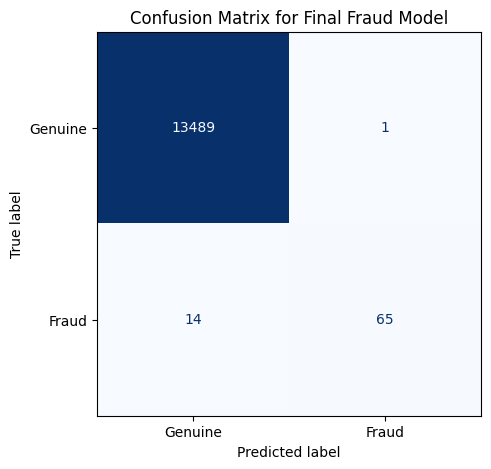

In [13]:
#| label: fig-final-confusion
#| fig-cap: "Confusion matrix for the final histogram-based gradient boosting fraud classifier on the test set. The model correctly identifies most fraudulent transactions while producing almost no false positives."
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine", "Fraud"]
)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Confusion Matrix for Final Fraud Model")
plt.tight_layout()
plt.show()

In [14]:
# serialize model
dump(final_model, "fraud.joblib", compress=9)

['fraud.joblib']

## Discussion

Based on the test results, it is strong enough to be used as a real-time fraud screening tool that flags suspicious transactions for additional action. The biggest benefit of the model is that it catches a large share of fraud while creating almost no friction for legitimate customers. In the test set, only one genuine transaction was flagged incorrectly, which suggests the model is very conservative in a good way. For a loss minimization team, this is valuable because it reduces fraud losses without creating large volumes of unnecessary customer complaints.

At the same time, the model still missed 14 out of 79 fraudulent transactions, so it should not be treated as a perfect fraud blocker. That miss rate matters because in real banking settings, even a small number of undetected fraudulent transactions can translate into meaningful financial losses. In addition, the model was evaluated on a fixed test set, not on live production traffic. Fraud patterns change over time as bad actors adapt their behavior, so performance in deployment could be worse than performance in the notebook. This risk is especially important in fraud detection because data drift is common and attackers are not static.

Another limitation is interpretability. Most of the predictors are anonymized principal components rather than business-readable transaction features. That means the model may predict well, but it is harder to explain exactly why a specific transaction was flagged. This reduces transparency for stakeholders and can make model monitoring more difficult. There is also a modeling limitation in the fact that the fraud weighting choice was fixed at a specific value and the notebook evaluates only the final classification results. In practice, the bank would likely want to tune the decision threshold based on the business cost of false negatives versus false positives, rather than rely only on the default prediction cutoff.

Overall, I would recommend this model for real-world fraud screening, but only as a monitored decision-support layer.